In [146]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchinfo
from torchinfo import summary
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from tqdm.auto import tqdm
from timeit import default_timer as timer

In [48]:
transform=transforms.Compose([transforms.Resize(size=(128,128)),transforms.ToTensor()])

In [49]:
train_data=datasets.ImageFolder("pizza_steak_sushi/train",transform=transform)

In [50]:
test_data=datasets.ImageFolder("pizza_steak_sushi/test",transform=transform)

In [51]:
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [52]:
train_dataloader=DataLoader(train_data,batch_size=8,shuffle=True)
test_dataloader=DataLoader(test_data,batch_size=8,shuffle=False)

In [53]:
len(train_dataloader),len(test_dataloader)

(29, 10)

In [54]:
img, label = train_data[0]

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

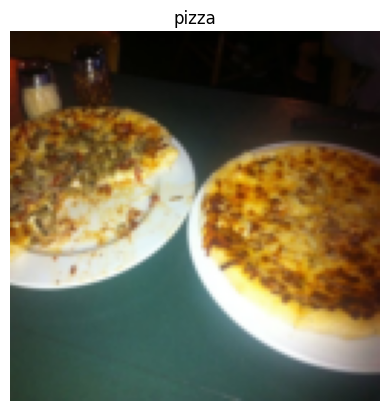

In [55]:
plt.imshow(img.permute(1,2,0))
plt.title(train_data.classes[label])
plt.axis("off")

In [108]:
class TinyVGG(nn.Module):
    def __init__(self,input_shape,hidden_units,output_shape):
        super().__init__()

        self.conv_block1=nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,
                stride=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,
                stride=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                        stride=2)
        )
        
        self.conv_block2=nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,
                stride=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,
                stride=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                        stride=2)
        )

        self.classifier=nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*32*32,
                     out_features=output_shape)
        )

    def forward(self,x):
        return self.classifier(self.conv_block2(self.conv_block1(x)))

In [109]:
model=TinyVGG(3,10,len(train_data.classes))
model

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=10240, out_features=3, bias=True)
  )
)

In [110]:
summary(model, input_size=(32, 3, 128, 128))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 64, 64]          --
│    └─Conv2d: 2-1                       [32, 10, 128, 128]        280
│    └─ReLU: 2-2                         [32, 10, 128, 128]        --
│    └─Conv2d: 2-3                       [32, 10, 128, 128]        910
│    └─ReLU: 2-4                         [32, 10, 128, 128]        --
│    └─MaxPool2d: 2-5                    [32, 10, 64, 64]          --
├─Sequential: 1-2                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-6                       [32, 10, 64, 64]          910
│    └─ReLU: 2-7                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-8                       [32, 10, 64, 64]          910
│    └─ReLU: 2-9                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-10                   [32, 10, 32, 32]          --
├─Sequentia

In [111]:
def training_pipeline(model,data_loader,loss_func,optimizer):
    training_loss,training_accuracy=0,0
    for x,y in data_loader:
        model.train()
        y_logit=model(x)
        loss=loss_func(y_logit,y)
        training_loss+=loss
        training_accuracy+=accuracy_score(y,y_logit.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    training_loss/=len(data_loader)
    training_accuracy/=len(data_loader)
    print(f"Training loss is {training_loss}")
    print(f"Training accuracy is {training_accuracy}")

In [112]:
def testing_pipeline(model,data_loader,loss_func):
    loss,accuracy=0,0
    model.eval()
    with torch.inference_mode():
        for x,y in data_loader:
            y_logit=model(x)
            loss+=loss_func(y_logit,y)
            accuracy+=accuracy_score(y,y_logit.argmax(dim=1))
        loss/=len(data_loader)
        accuracy/=len(data_loader)
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": accuracy}

In [113]:
optimizer=torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=0.0001)
loss_func=nn.CrossEntropyLoss()

In [114]:
epochs=30
start_time=timer()
for epoch in tqdm(range(epochs)):
    print(f"-----Epoch {epoch+1}-----")
    training_pipeline(model,train_dataloader,loss_func,optimizer)
end_time=timer()
print(f"Time taken for training is {end_time-start_time}.")

  0%|          | 0/30 [00:00<?, ?it/s]

-----Epoch 1-----
Training loss is 1.11320960521698
Training accuracy is 0.3620689655172414
-----Epoch 2-----
Training loss is 1.042773723602295
Training accuracy is 0.5
-----Epoch 3-----
Training loss is 0.9487754106521606
Training accuracy is 0.5603448275862069
-----Epoch 4-----
Training loss is 0.9062550067901611
Training accuracy is 0.5646551724137931
-----Epoch 5-----
Training loss is 0.856685221195221
Training accuracy is 0.625
-----Epoch 6-----
Training loss is 0.7424174547195435
Training accuracy is 0.6896551724137931
-----Epoch 7-----
Training loss is 0.6269599795341492
Training accuracy is 0.7456896551724138
-----Epoch 8-----
Training loss is 0.53891521692276
Training accuracy is 0.7844827586206896
-----Epoch 9-----
Training loss is 0.4063389301300049
Training accuracy is 0.8706896551724138
-----Epoch 10-----
Training loss is 0.5031339526176453
Training accuracy is 0.8103448275862069
-----Epoch 11-----
Training loss is 0.2237786054611206
Training accuracy is 0.926724137931034

In [116]:
model_results=testing_pipeline(model,test_dataloader,loss_func)
model_results

{'model_name': 'TinyVGG',
 'model_loss': 2.3701319694519043,
 'model_acc': 0.4333333333333333}

In [135]:
augment_transform=transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

In [136]:
train_data_augmented=datasets.ImageFolder("pizza_steak_sushi/train",transform=augment_transform)

In [137]:
train_data_augmented

Dataset ImageFolder
    Number of datapoints: 225
    Root location: pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
           )

In [138]:
augmented_train_dataloader=DataLoader(train_data_augmented,batch_size=8,shuffle=True)

In [139]:
len(augmented_train_dataloader)

29

In [140]:
augmented_model=TinyVGG(3,10,len(train_data_augmented.classes))
augmented_model

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=10240, out_features=3, bias=True)
  )
)

In [141]:
augmented_loss_func=nn.CrossEntropyLoss()
augmented_optimizer=torch.optim.Adam(augmented_model.parameters(),lr=0.001,weight_decay=0.0001)

In [142]:
epochs=30
start_time=timer()
for epoch in tqdm(range(epochs)):
    print(f"-----Epoch {epoch+1}-----")
    training_pipeline(augmented_model,augmented_train_dataloader,augmented_loss_func,augmented_optimizer)
end_time=timer()
print(f"Time taken for training is {end_time-start_time}.")

  0%|          | 0/30 [00:00<?, ?it/s]

-----Epoch 1-----
Training loss is 1.1305882930755615
Training accuracy is 0.3103448275862069
-----Epoch 2-----
Training loss is 1.0685251951217651
Training accuracy is 0.41810344827586204
-----Epoch 3-----
Training loss is 0.9876972436904907
Training accuracy is 0.5129310344827587
-----Epoch 4-----
Training loss is 0.8841623663902283
Training accuracy is 0.625
-----Epoch 5-----
Training loss is 0.8476134538650513
Training accuracy is 0.6293103448275862
-----Epoch 6-----
Training loss is 0.8295294642448425
Training accuracy is 0.6293103448275862
-----Epoch 7-----
Training loss is 0.7891351580619812
Training accuracy is 0.646551724137931
-----Epoch 8-----
Training loss is 0.8336232900619507
Training accuracy is 0.6120689655172413
-----Epoch 9-----
Training loss is 0.749117910861969
Training accuracy is 0.6422413793103449
-----Epoch 10-----
Training loss is 0.7646197080612183
Training accuracy is 0.6379310344827587
-----Epoch 11-----
Training loss is 0.7694841623306274
Training accuracy 

In [144]:
augmented_model_results=testing_pipeline(augmented_model,test_dataloader,augmented_loss_func)
augmented_model_results

{'model_name': 'TinyVGG',
 'model_loss': 1.4246761798858643,
 'model_acc': 0.5291666666666667}

In [179]:
custom_image=torchvision.io.read_image("Pizza.jpg").type(torch.float32)/255

In [180]:
custom_image

tensor([[[0.0314, 0.0392, 0.0471,  ..., 0.1020, 0.1098, 0.1216],
         [0.0314, 0.0353, 0.0431,  ..., 0.0824, 0.0902, 0.1020],
         [0.0314, 0.0353, 0.0431,  ..., 0.0706, 0.0784, 0.0863],
         ...,
         [0.3569, 0.3569, 0.3569,  ..., 0.9608, 0.9608, 0.9608],
         [0.3569, 0.3569, 0.3569,  ..., 0.9608, 0.9569, 0.9569],
         [0.3647, 0.3647, 0.3569,  ..., 0.9569, 0.9608, 0.9608]],

        [[0.0392, 0.0471, 0.0471,  ..., 0.0745, 0.0824, 0.0941],
         [0.0392, 0.0431, 0.0431,  ..., 0.0627, 0.0706, 0.0824],
         [0.0392, 0.0431, 0.0431,  ..., 0.0588, 0.0667, 0.0745],
         ...,
         [0.2118, 0.2118, 0.2118,  ..., 0.9255, 0.9255, 0.9255],
         [0.2039, 0.2039, 0.2039,  ..., 0.9216, 0.9216, 0.9216],
         [0.1961, 0.1961, 0.2000,  ..., 0.9176, 0.9216, 0.9216]],

        [[0.0353, 0.0431, 0.0392,  ..., 0.0510, 0.0588, 0.0706],
         [0.0353, 0.0392, 0.0353,  ..., 0.0392, 0.0471, 0.0588],
         [0.0275, 0.0314, 0.0353,  ..., 0.0392, 0.0471, 0.

In [181]:
custom_image.shape

torch.Size([3, 1536, 2048])

In [182]:
transformer=transforms.Compose([transforms.Resize(size=(128,128))])

In [183]:
transformed_custom_image=transformer(custom_image)

In [184]:
transformed_custom_image.shape

torch.Size([3, 128, 128])

In [185]:
transformed_custom_image=transformed_custom_image.unsqueeze(0)

In [186]:
transformed_custom_image.shape

torch.Size([1, 3, 128, 128])

In [187]:
augmented_model.eval()
with torch.inference_mode():
    prediction=augmented_model(transformed_custom_image)

In [188]:
prediction

tensor([[ 0.1813, -3.8676, -0.3757]])

In [189]:
train_data_augmented.classes

['pizza', 'steak', 'sushi']

In [190]:
train_data_augmented.classes[prediction.argmax(dim=1)]

'pizza'

In [191]:
probabilities=torch.softmax(prediction,dim=1)

Text(0.5, 1.0, 'pizza')

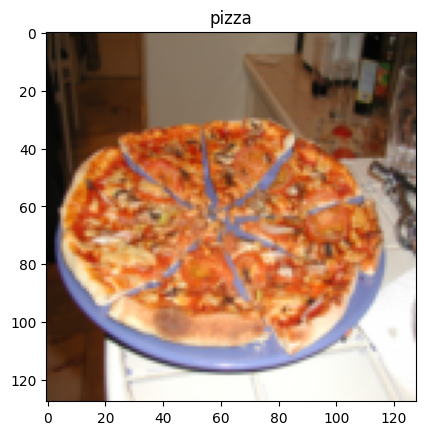

In [193]:
plt.imshow(transformed_custom_image.squeeze().permute(1,2,0))
plt.title(train_data_augmented.classes[prediction.argmax(dim=1)])